# 🏭 제품 수요 예측 — RNN / LSTM / GRU 모델 비교
과거 주문 데이터를 분석하여 **SimpleRNN, LSTM, GRU** 세 모델의 예측 성능을 비교합니다.

## 1. 라이브러리 임포트

In [19]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import display

print('✅ 라이브러리 임포트 완료')

✅ 라이브러리 임포트 완료


## 2. 데이터 로드

In [20]:
df = pd.read_csv('archive/Historical Product Demand.csv')
print('=' * 50)
print('1. 데이터 로드')
print('=' * 50)
print(df.shape)
print(df.dtypes)
display(df.head(10))

1. 데이터 로드
(1048575, 5)
Product_Code        object
Warehouse           object
Product_Category    object
Date                object
Order_Demand        object
dtype: object


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500
5,Product_0979,Whse_J,Category_028,2012/4/19,500
6,Product_0979,Whse_J,Category_028,2012/6/5,500
7,Product_0979,Whse_J,Category_028,2012/6/27,500
8,Product_0979,Whse_J,Category_028,2012/7/23,500
9,Product_0979,Whse_J,Category_028,2012/8/29,500


## 3. 전처리 전 — 결측치 통계

In [21]:
print('=' * 50)
print('2. 전처리 전 - 결측치 통계')
print('=' * 50)
print(df.isnull().sum())
print(f'\n중복 행: {df.duplicated().sum()}')
print(f'데이터 크기: {df.shape[0]:,} 행, {df.shape[1]} 열')

2. 전처리 전 - 결측치 통계
Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

중복 행: 122423
데이터 크기: 1,048,575 행, 5 열


## 4. 전처리

In [22]:
def clean_demand(val):
    val = str(val).strip()
    if val.startswith('(') and val.endswith(')'):
        try:
            return -float(val[1:-1].replace(',', ''))
        except:
            return np.nan
    try:
        return float(val.replace(',', ''))
    except:
        return np.nan

df['Order_Demand'] = df['Order_Demand'].apply(clean_demand)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date', 'Order_Demand'])
df = df[df['Order_Demand'] > 0]
df['YearMonth'] = df['Date'].dt.to_period('M')
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print('=' * 50)
print('3. 전처리 후 - 결측치 통계')
print('=' * 50)
print(df.isnull().sum())
print(f'\n전처리 후 데이터: {df.shape[0]:,} 행')

3. 전처리 후 - 결측치 통계
Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
YearMonth           0
Year                0
Month               0
dtype: int64

전처리 후 데이터: 1,002,765 행


## 5. 카테고리 선택 및 월별 집계

In [ ]:
top_category = df['Product_Category'].value_counts().index[0]
filtered = df[df['Product_Category'] == top_category]

monthly = (
    filtered``
    .groupby('YearMonth')['Order_Demand']
    .sum()
    .reset_index()
    .sort_values('YearMonth')
)
monthly['date']  = monthly['YearMonth'].dt.to_timestamp()
monthly['year']  = monthly['YearMonth'].dt.year
monthly['month'] = monthly['YearMonth'].dt.month

print(f'선택 카테고리: {top_category}')
print(f'월별 데이터: {len(monthly)}개월')
display(monthly.head())

선택 카테고리: Category_019
월별 데이터: 66개월


,YearMonth,Order_Demand,date,year,month
0,2011-06,92000.0,2011-06-01,2011,6
1,2011-09,1250.0,2011-09-01,2011,9
2,2011-10,3.0,2011-10-01,2011,10
3,2011-11,57250.0,2011-11-01,2011,11
4,2011-12,6376792.0,2011-12-01,2011,12


## 6. Histogram — Order_Demand 분포

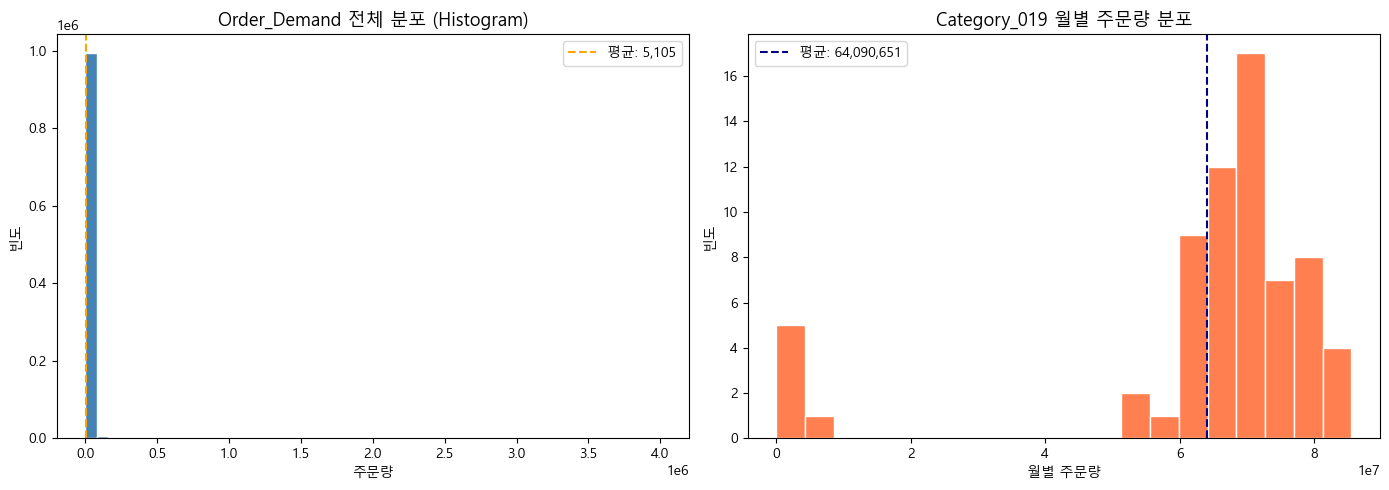

✅ 01_histogram.png 저장 완료


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Order_Demand'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Order_Demand 전체 분포 (Histogram)', fontsize=13)
axes[0].set_xlabel('주문량')
axes[0].set_ylabel('빈도')
axes[0].axvline(df['Order_Demand'].mean(), color='orange', linestyle='--',
                label=f"평균: {df['Order_Demand'].mean():,.0f}")
axes[0].legend()

axes[1].hist(monthly['Order_Demand'], bins=20, color='coral', edgecolor='white')
axes[1].set_title(f'{top_category} 월별 주문량 분포', fontsize=13)
axes[1].set_xlabel('월별 주문량')
axes[1].set_ylabel('빈도')
axes[1].axvline(monthly['Order_Demand'].mean(), color='navy', linestyle='--',
                label=f"평균: {monthly['Order_Demand'].mean():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('01_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 01_histogram.png 저장 완료')

## 7. Heatmap — 연도 × 월 계절성

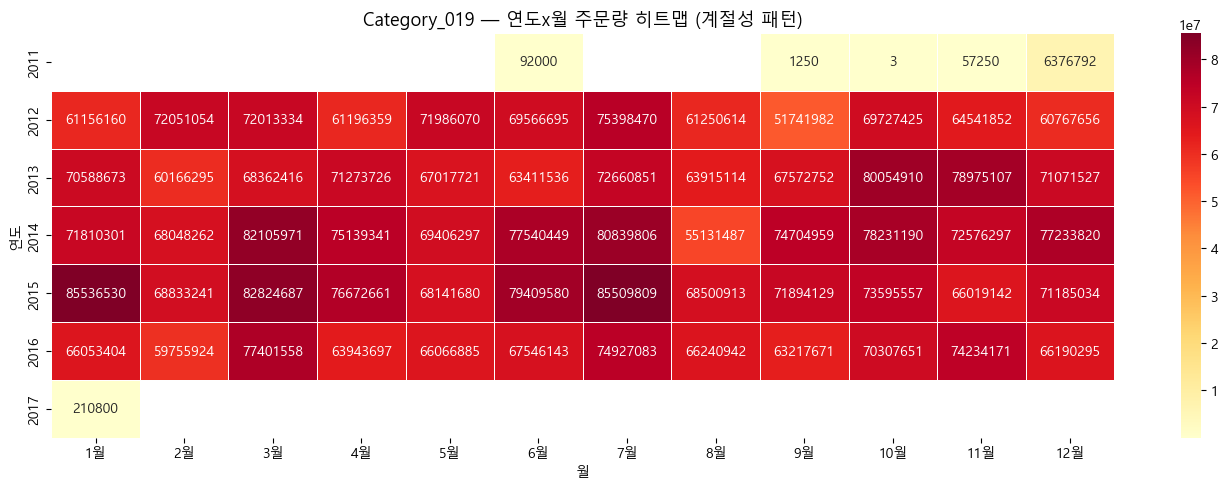

✅ 02_heatmap.png 저장 완료


In [25]:
pivot = monthly.pivot_table(
    values='Order_Demand', index='year', columns='month', aggfunc='sum'
)
pivot.columns = ['1월','2월','3월','4월','5월','6월',
                 '7월','8월','9월','10월','11월','12월']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title(f'{top_category} — 연도x월 주문량 히트맵 (계절성 패턴)', fontsize=13)
ax.set_xlabel('월')
ax.set_ylabel('연도')
plt.tight_layout()
plt.savefig('02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 02_heatmap.png 저장 완료')

## 8. 월별 주문량 추이

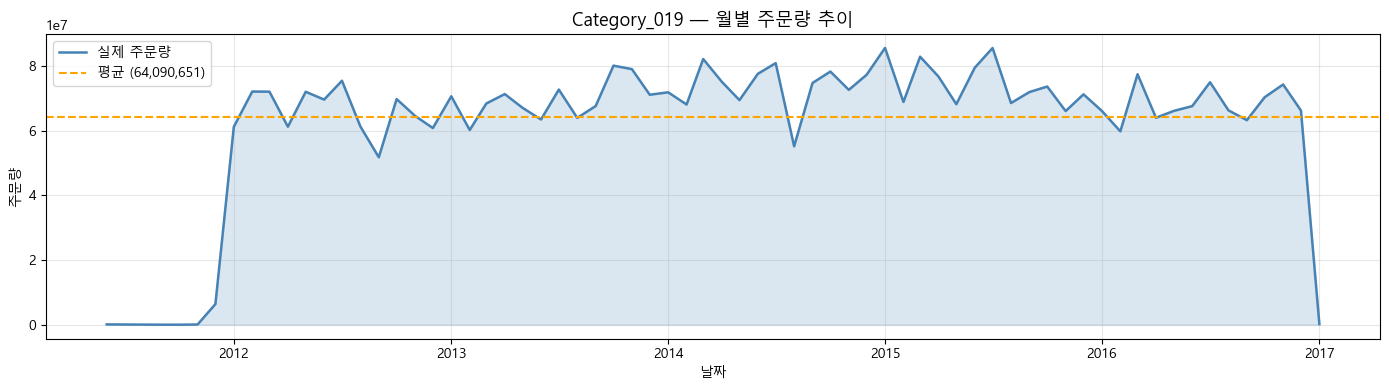

✅ 03_trend.png 저장 완료


In [26]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['date'], monthly['Order_Demand'],
        color='steelblue', linewidth=1.8, label='실제 주문량')
ax.fill_between(monthly['date'], monthly['Order_Demand'], alpha=0.2, color='steelblue')
avg = monthly['Order_Demand'].mean()
ax.axhline(avg, color='orange', linestyle='--', label=f'평균 ({avg:,.0f})')
ax.set_title(f'{top_category} — 월별 주문량 추이', fontsize=13)
ax.set_xlabel('날짜')
ax.set_ylabel('주문량')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 03_trend.png 저장 완료')

## 9. 데이터 전처리 — 시퀀스 생성 (Train / Test 분리)

In [27]:
TIME_STEPS = 12
values = monthly['Order_Demand'].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

X, y = [], []
for i in range(len(scaled) - TIME_STEPS):
    X.append(scaled[i : i + TIME_STEPS])
    y.append(scaled[i + TIME_STEPS])
X, y = np.array(X), np.array(y)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (43, 12, 1), X_test: (11, 12, 1)


## 10. 모델 정의

In [28]:
def build_model(layer_type, units1=64, units2=32):
    model = Sequential()
    if layer_type == 'SimpleRNN':
        model.add(SimpleRNN(units1, return_sequences=True, input_shape=(TIME_STEPS, 1)))
        model.add(Dropout(0.2))
        model.add(SimpleRNN(units2))
    elif layer_type == 'LSTM':
        model.add(LSTM(units1, return_sequences=True, input_shape=(TIME_STEPS, 1)))
        model.add(Dropout(0.2))
        model.add(LSTM(units2))
    elif layer_type == 'GRU':
        model.add(GRU(units1, return_sequences=True, input_shape=(TIME_STEPS, 1)))
        model.add(Dropout(0.2))
        model.add(GRU(units2))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

es = EarlyStopping(patience=15, restore_best_weights=True)

def evaluate_model(y_true, y_pred):
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    return {
        'RMSE': mean_squared_error(y_true_inv, y_pred_inv) ** 0.5,
        'MAE':  mean_absolute_error(y_true_inv, y_pred_inv),
        'R2':   r2_score(y_true_inv, y_pred_inv)
    }, y_true_inv, y_pred_inv

print('✅ 모델 빌더 / 평가 함수 정의 완료')

✅ 모델 빌더 / 평가 함수 정의 완료


## 11. SimpleRNN 학습

In [29]:
print('[SimpleRNN 학습 중...]')
rnn = build_model('SimpleRNN')
rnn.summary()
rnn_hist = rnn.fit(X_train, y_train, epochs=150, batch_size=8,
                   validation_split=0.1, verbose=1, callbacks=[es])
rnn_pred = rnn.predict(X_test, verbose=0)
rnn_score, y_true_inv, rnn_inv = evaluate_model(y_test, rnn_pred)
print(f"\nSimpleRNN — RMSE: {rnn_score['RMSE']:,.2f} | MAE: {rnn_score['MAE']:,.2f} | R2: {rnn_score['R2']:.4f}")

[SimpleRNN 학습 중...]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 12, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.3048 - val_loss: 0.1401
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3993 - val_loss: 0.0977
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3121 - val_loss: 0.0099
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3773 - val_loss: 0.2404
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3494 - val_loss: 0.0058
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1900 - val_loss: 0.0064
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2660 - val_loss: 0.0591
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2580 - val_loss: 0.0845
Epoch 9/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2239 - val_loss: 0.1851
Epoch 10/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1709 - val_loss: 0.0926
Epoch 11/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2715 - val_loss: 0.1198
Epoch 12/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2222 - val_lo

## 12. LSTM 학습

In [30]:
print('[LSTM 학습 중...]')
lstm = build_model('LSTM')
lstm.summary()
lstm_hist = lstm.fit(X_train, y_train, epochs=150, batch_size=8,
                     validation_split=0.1, verbose=1, callbacks=[es])
lstm_pred = lstm.predict(X_test, verbose=0)
lstm_score, _, lstm_inv = evaluate_model(y_test, lstm_pred)
print(f"\nLSTM      — RMSE: {lstm_score['RMSE']:,.2f} | MAE: {lstm_score['MAE']:,.2f} | R2: {lstm_score['R2']:.4f}")

[LSTM 학습 중...]


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.4898 - val_loss: 0.1692
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1392 - val_loss: 0.0064
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0376 - val_loss: 0.1253
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0516 - val_loss: 0.0313
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0187 - val_loss: 0.0025
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0375 - val_loss: 0.0031
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0276 - val_loss: 0.0059
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0175 - val_loss: 0.0264
Epoch 9/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0230 - val_loss: 0.0192
Epoch 10/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0130 - val_loss: 0.0058
Epoch 11/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0180 - val_loss: 0.0048
Epoch 12/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0225 - val_l

## 13. GRU 학습

In [31]:
print('[GRU 학습 중...]')
gru = build_model('GRU')
gru.summary()
gru_hist = gru.fit(X_train, y_train, epochs=150, batch_size=8,
                   validation_split=0.1, verbose=1, callbacks=[es])
gru_pred = gru.predict(X_test, verbose=0)
gru_score, _, gru_inv = evaluate_model(y_test, gru_pred)
print(f"\nGRU       — RMSE: {gru_score['RMSE']:,.2f} | MAE: {gru_score['MAE']:,.2f} | R2: {gru_score['R2']:.4f}")

[GRU 학습 중...]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 0.6925 - val_loss: 0.2932
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2409 - val_loss: 0.0259
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0366 - val_loss: 0.0478
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0582 - val_loss: 0.0718
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0511 - val_loss: 0.0068
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0207 - val_loss: 0.0034
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0361 - val_loss: 0.0032
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0183 - val_loss: 0.0022
Epoch 9/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0153 - val_loss: 0.0039
Epoch 10/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0166 - val_loss: 0.0104
Epoch 11/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0229 - val_loss: 0.0130
Epoch 12/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0186 - val_l

## 14. 학습 곡선 시각화 (Loss)

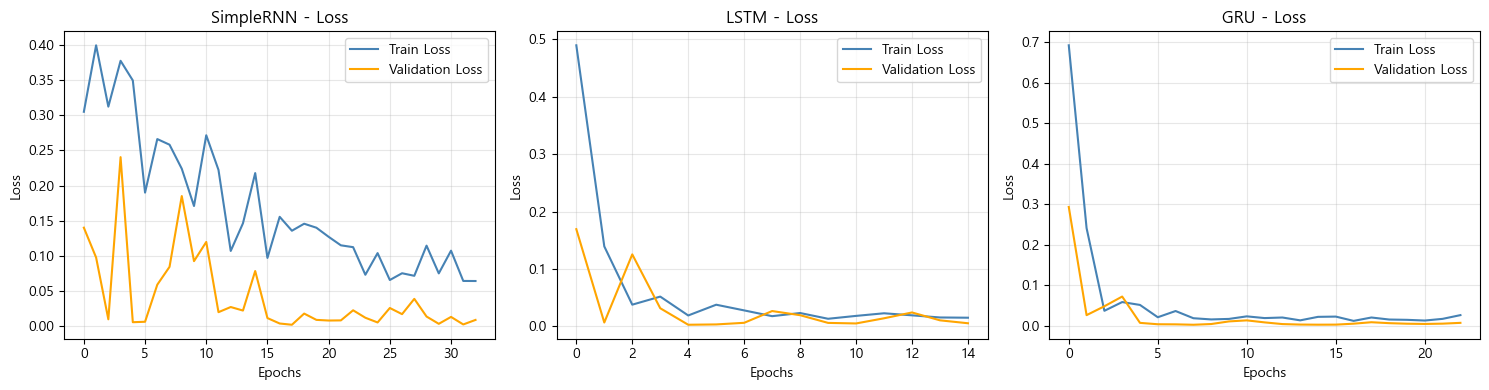

✅ 04_loss_curve.png 저장 완료


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, hist, title in zip(
    axes,
    [rnn_hist, lstm_hist, gru_hist],
    ['SimpleRNN - Loss', 'LSTM - Loss', 'GRU - Loss']
):
    ax.plot(hist.history['loss'], label='Train Loss', color='steelblue')
    ax.plot(hist.history['val_loss'], label='Validation Loss', color='orange')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 04_loss_curve.png 저장 완료')

## 15. 모델 비교 — Scatter (실제 vs 예측)

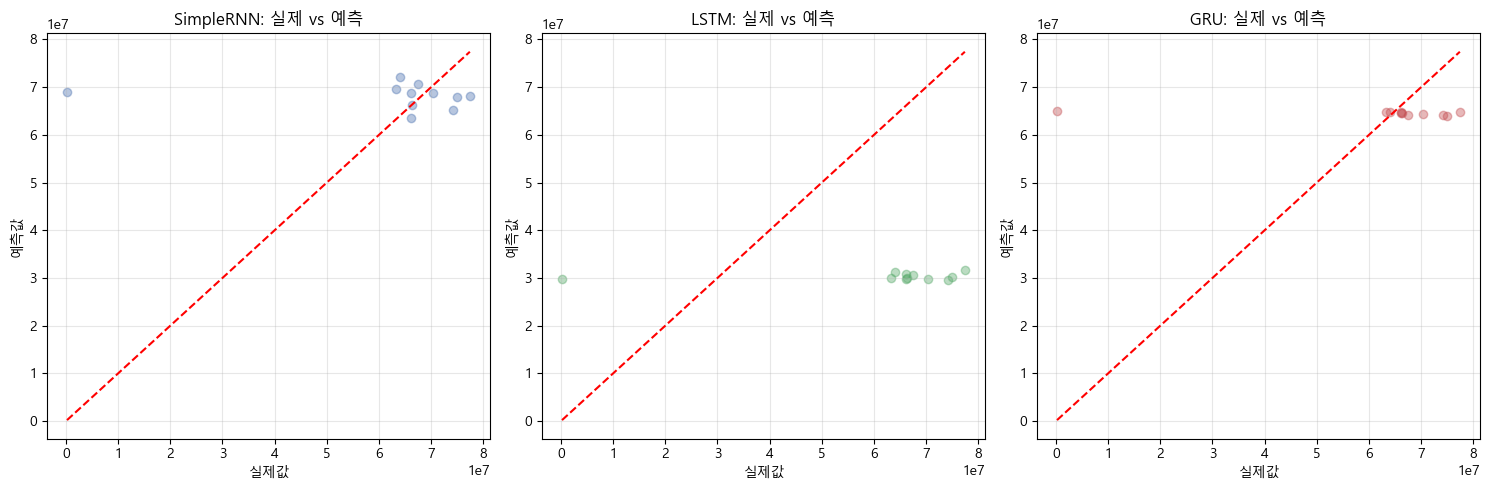

✅ 05_model_compare_scatter.png 저장 완료


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, y_pred, title, color in zip(
    axes,
    [rnn_inv, lstm_inv, gru_inv],
    ['SimpleRNN: 실제 vs 예측', 'LSTM: 실제 vs 예측', 'GRU: 실제 vs 예측'],
    ['#4C72B0', '#55A868', '#C44E52']
):
    ax.scatter(y_true_inv, y_pred, alpha=0.4, color=color)
    ax.plot([y_true_inv.min(), y_true_inv.max()],
            [y_true_inv.min(), y_true_inv.max()], 'r--', linewidth=1.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('실제값')
    ax.set_ylabel('예측값')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_model_compare_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 05_model_compare_scatter.png 저장 완료')

## 16. 성능 비교 바차트

모델 성능 비교


,모델,RMSE,MAE,R2
0,SimpleRNN,2.146963e+07,1.074367e+07,-0.121080
1,LSTM,3.816429e+07,3.781777e+07,-2.542436
2,GRU,2.049940e+07,1.043375e+07,-0.022045


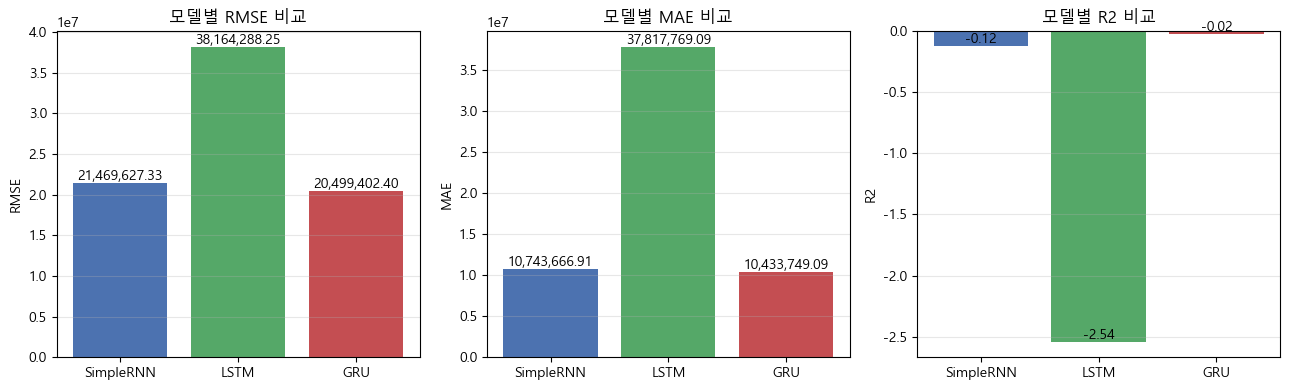

✅ 06_model_compare_bar.png 저장 완료


In [34]:
results = pd.DataFrame({
    '모델':  ['SimpleRNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_score['RMSE'], lstm_score['RMSE'], gru_score['RMSE']],
    'MAE':  [rnn_score['MAE'],  lstm_score['MAE'],  gru_score['MAE']],
    'R2':   [rnn_score['R2'],   lstm_score['R2'],   gru_score['R2']]
})

print('=' * 50)
print('모델 성능 비교')
print('=' * 50)
display(results)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(results['모델'], results[metric], color=colors)
    ax.set_title(f'모델별 {metric} 비교', fontsize=12)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(), f'{val:,.2f}',
                ha='center', va='bottom', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('06_model_compare_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 06_model_compare_bar.png 저장 완료')

## 17. LSTM 실제값 vs 예측값 시계열 그래프

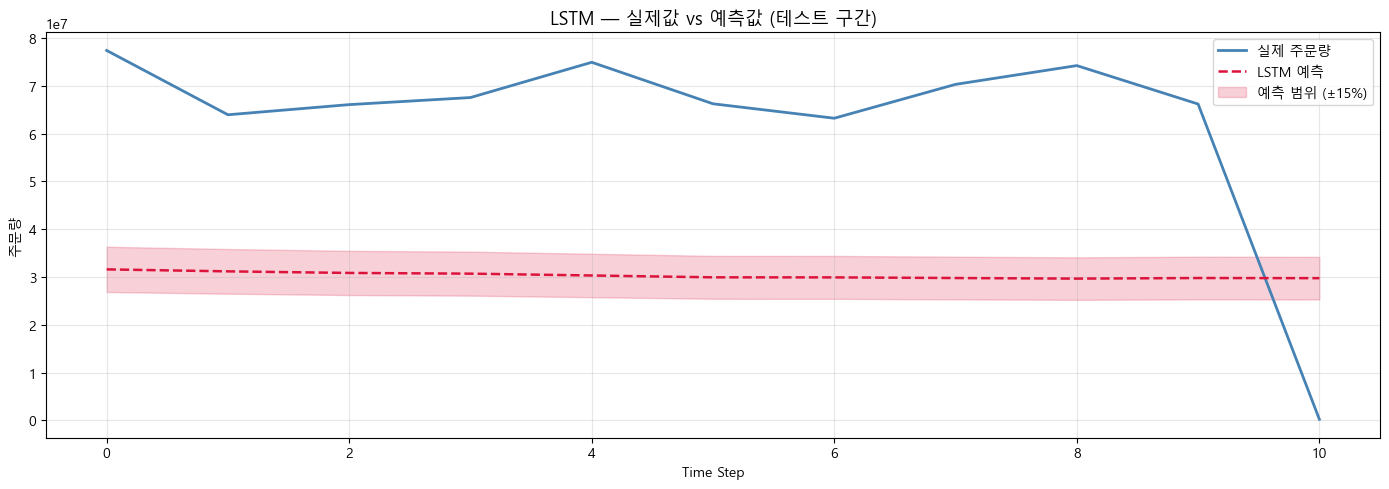

✅ 07_actual_vs_predicted.png 저장 완료


In [35]:
fig, ax = plt.subplots(figsize=(14, 5))
x_axis = range(len(y_true_inv))

ax.plot(x_axis, y_true_inv, label='실제 주문량', color='steelblue', linewidth=2)
ax.plot(x_axis, lstm_inv, label='LSTM 예측', color='crimson', linestyle='--', linewidth=1.8)
ax.fill_between(x_axis,
                lstm_inv * 0.85, lstm_inv * 1.15,
                alpha=0.2, color='crimson', label='예측 범위 (±15%)')
ax.set_title('LSTM — 실제값 vs 예측값 (테스트 구간)', fontsize=13)
ax.set_xlabel('Time Step')
ax.set_ylabel('주문량')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 07_actual_vs_predicted.png 저장 완료')